### Import Data and Required Packages

##### **Import pandas, Numpy, Matplotlib, Seaborn and warnings liabrary.**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime as dt
import plotly.express as px
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline


**We will set the pandas.set_option to display 100 rows or columns. By default it is 60**

In [3]:
pd.set_option("display.max_columns",100)
pd.set_option("display.max_rows",100)

In [4]:
df = pd.read_excel(r"C:\Users\ACER\OneDrive\Desktop\ML Notes and colab Notebooks\Data Science Projects\Customer-Categorization-new\notebooks\data\marketing_campaign_data.xlsx")

**Making copy of dataset for future reference**

In [5]:
raw_df = df.copy()

In [6]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                  object
Kidhome                  int64
Teenhome                object
Dt_Customer             object
Recency                 object
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response               float64
Unnamed: 29            float64
dtype: object

In [7]:
df.sample(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Unnamed: 29
1600,5272,1965,Master,Married,53843,0,1,2013-06-27 00:00:00,64,378,0,88,19,4,73,4,8,5,3,7,0,0,0,0,0,0,3,11,0.0,NaN
1373,5675,1960,PhD,Divorced,50611,0,1,2012-10-04 00:00:00,98,459,0,24,6,0,4,6,4,5,7,6,0,1,0,0,0,0,3,11,0.0,NaN
1470,9672,1970,2n,Cycle,Married,23162,1,1,2013-12-21 00:00:00,82,8,3,9,19,4,22,3,1,1,3,6,0,0,0,0,0,0,3,11.0,0.0
875,4789,1953,Graduation,Together,80812,0,0,2013-09-17 00:00:00,95,769,22,500,210,143,33,1,4,8,5,2,1,0,1,1,0,0,3,11,0.0,NaN
1243,7718,1947,Master,Together,66000,0,0,2014-04-20 00:00:00,36,244,51,270,101,0,45,1,1,3,5,1,0,0,0,0,0,0,3,11,0.0,NaN
1747,7881,1946,Master,Married,66835,0,0,2013-09-28 00:00:00,21,620,26,195,34,17,141,1,6,4,13,2,0,0,0,0,0,0,3,11,0.0,NaN
1738,10556,1959,Graduation,Married,54984,0,1,2014-05-24 00:00:00,51,173,13,131,32,3,6,4,6,1,6,7,0,0,0,1,0,0,3,11,0.0,NaN
1221,1176,1973,Graduation,Married,26228,1,0,2013-09-22 00:00:00,50,2,6,4,3,1,9,1,1,0,2,8,0,0,0,0,0,0,3,11,0.0,NaN
1121,4713,1979,PhD,Married,31605,1,0,2012-11-22 00:00:00,15,74,0,42,2,1,6,2,2,1,4,7,0,0,0,0,0,0,3,11,0.0,NaN
434,498,1970,Graduation,Single,30015,1,0,2014-02-02 00:00:00,28,25,0,22,2,3,5,2,1,0,4,5,0,0,0,0,0,0,3,11,0.0,NaN


**Found column with interesting name hence digging more about it**

In [8]:
df['Unnamed: 29'].unique()

array([nan,  0.,  1.])

**General shape of dataset**

In [9]:
df.shape

(2240, 30)

**datatypes of dataset**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   object 
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   object 
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   object 
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# Exploring Data

In [11]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Unnamed: 29
0,5524,1957,Graduation,Single,58138,0,0,2012-09-04 00:00:00,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1.0,NaN
1,2174,1954,Graduation,Single,46344,1,1,2014-03-08 00:00:00,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0.0,NaN
2,4141,1965,Graduation,Together,71613,0,0,2013-08-21 00:00:00,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0.0,NaN
3,6182,1984,Graduation,Together,26646,1,0,2014-02-10 00:00:00,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0.0,NaN
4,5324,1981,PhD,Married,58293,1,0,2014-01-19 00:00:00,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223,0,1,2013-06-13 00:00:00,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0.0,NaN
2236,4001,1946,PhD,Together,64014,2,1,2014-06-10 00:00:00,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0.0,NaN
2237,7270,1981,Graduation,Divorced,56981,0,0,2014-01-25 00:00:00,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0.0,NaN
2238,8235,1956,Master,Together,69245,0,1,2014-01-24 00:00:00,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0.0,NaN


**As we can see froom above dtypes Dt_Customer is an object type of data lets convert it into datetime format**

In [12]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],format='mixed')
#CHECK DTYPE
df["Dt_Customer"].dtype

dtype('<M8[ns]')

In [13]:
df = df.drop(columns="Unnamed: 29", axis = 1)

In [14]:
## define numerical and categorical columns and drop ID column(as its not usefull in ML)
# convert Income column to numeric
df.select_dtypes('object')
w = ["Together", "Single","Married","Divorced","Widow"]

for i in w:
    df = df.drop(df.index[df["Income"] == (i)])

df.Income = pd.to_numeric(df.Income)
# convert Teenhome column to numeric
w = ["1", "2","0"]

for i in w:
    df = df[df.Teenhome.astype('str').isin(w)]
df.Teenhome = pd.to_numeric(df.Teenhome)
# convert Recency column to numeric
df.Recency = pd.to_numeric(df.Recency)

cat_features = df.select_dtypes('object').columns.tolist()
num_features = df.select_dtypes('number').columns.tolist()
print(f"no. of numeric columns{num_features},{len(num_features)}\n,no. of categorical:{cat_features},{len(cat_features)}")

no. of numeric columns['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],26
,no. of categorical:['Education', 'Marital_Status'],2


### Feature Information

- **People**

    - **ID:** Customer's unique identifier
    - **Year_Birth:** Customer's birth year
    - **Education:** Customer's education level
    - **Marital_Status:** Customer's marital status
    - **Income:** Customer's yearly household income
    - **Kidhome:** Number of children in customer's household
    - **Teenhome:** Number of teenagers in customer's household
    - **Dt_Customer:** Date of customer's enrollment with the company
    - **Recency:** Number of days since customer's last purchase
    - **Complain:** 1 if the customer complained in the last 2 years, 0 otherwise

- **Products**

    - **MntWines:** Amount spent on wine in last 2 years
    - **MntFruits:** Amount spent on fruits in last 2 years
    - **MntMeatProducts:** Amount spent on meat in last 2 years
    - **MntFishProducts:** Amount spent on fish in last 2 years
    - **MntSweetProducts:** Amount spent on sweets in last 2 years
    - **MntGoldProds:** Amount spent on gold in last 2 years

- **Promotion**

    - **NumDealsPurchases:** Number of purchases made with a discount
    - **AcceptedCmp1:** 1 if customer accepted the offer in the 1st campaign, 0 otherwise
    - **AcceptedCmp2:** 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
    - **AcceptedCmp3:** 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
    - **AcceptedCmp4:** 1 if customer accepted the offer in the 4th campaign, 0 otherwise
    - **AcceptedCmp5:** 1 if customer accepted the offer in the 5th campaign, 0 otherwise
    - **Response:** 1 if customer accepted the offer in the last campaign, 0 otherwise

- **Place**

    - **NumWebPurchases:** Number of purchases made through the company’s website
    - **NumCatalogPurchases:** Number of purchases made using a catalogue
    - **NumStorePurchases:** Number of purchases made directly in stores
    - **NumWebVisitsMonth:** Number of visits to company’s website in the last month

In [15]:
cat_features


['Education', 'Marital_Status']

In [16]:
for i in cat_features:
    print(df[i].value_counts(normalize = True)*100)
    print("-----------")

Education
Graduation    55.357143
PhD           23.859127
Master        18.105159
Basic          2.678571
Name: proportion, dtype: float64
-----------
Marital_Status
Married     38.541667
Together    25.644841
Single      21.577381
Divorced    10.367063
Widow        3.521825
Alone        0.148810
Absurd       0.099206
YOLO         0.099206
Name: proportion, dtype: float64
-----------


### Numerical Features

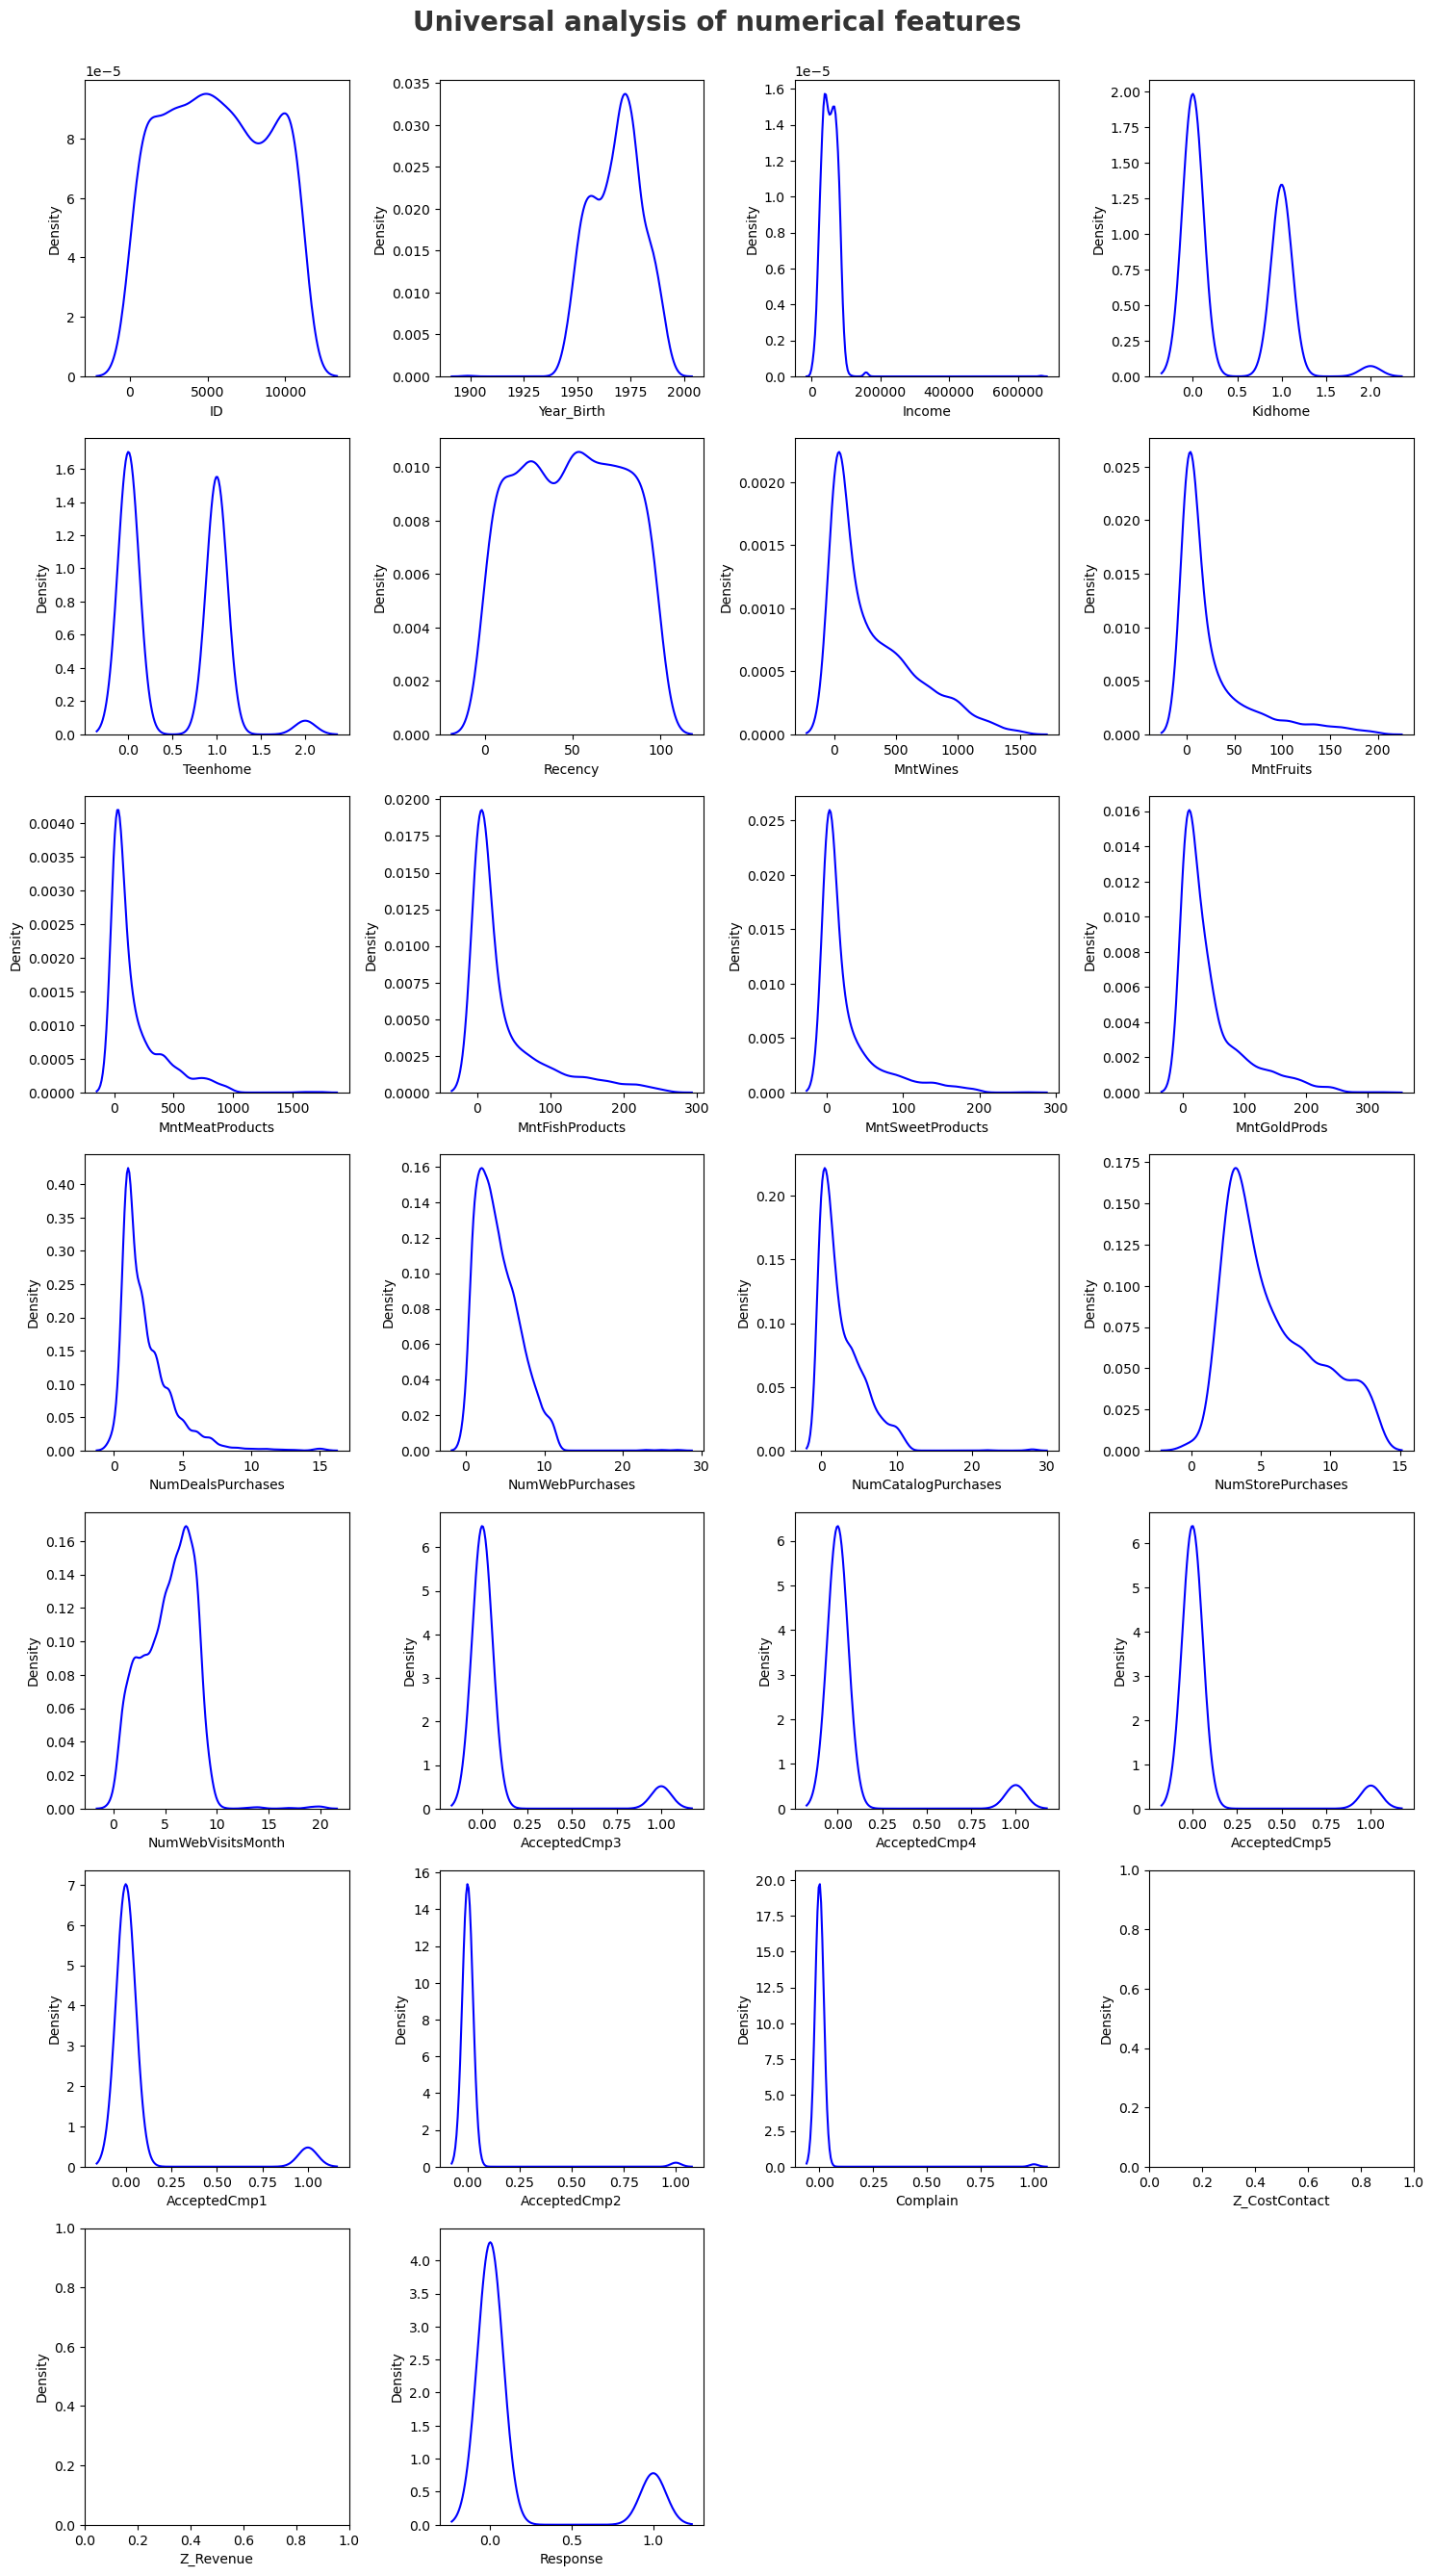

In [17]:

plt.figure(figsize = (15,30))
plt.suptitle("Universal analysis of numerical features", fontsize = 20, fontweight = 'bold', alpha = 0.8, y = 1.)

for i in range(0,len(num_features)):
    plt.subplot(8,4,i+1)
    sns.kdeplot(x=df[num_features[i]],color = 'blue')
    plt.xlabel(num_features[i])
    plt.tight_layout()


*Report of the univariate analytis*
1. `Year_Birth` is left-skewed, most of the values falls in 1940-2000 range and has outliers.
2. `Income` is right-skewed, most of the values falls in 0 - <200000 range and has outliers.
3. `Kidhome`, `Teenhome` has constant values. Most of the values seems to be 0 or 1 and some of the values are 2.
4. `Dt_customer`, `Recency` are following a normal distribution
5. `MntWines`, `MntMeatProducts` are right-skewed, most of the values falls in 0 - 500 range and has outliers.
6. `MntFruits`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` is right-skewed, most of the values falls in 0-50 range and has outliers.
7. `NumDealsPurchases` is right-skewed, most of the values falls in 0-5 range and has outliers.
8. `NumWebPurchases`, `NumCatalogPurchases` are right skewed and most of the values falls in 0-10 range and have outliers.
9. `NumStorePurchases` is almost following a normal distribution and most of the values falls in 1 - 10 range and has outliers.
10. `NumWebVisitsMonth` is right-skewed, most of the values falls in 0- 10 range and has outliers.
11. `AcceptedCmp3`, `AcceptedCmp4`, `AcceptedCmp5`, `AcceptedCmp1`,`AcceptedCmp2` is right skewed and most of the values are 0 and some of the values are 1.
12. `Complain` has most of the values as 0 and we can see a little bit of the values as 1. 
13. `Z_CostContact`, `Z_Revenue` columns are not showing any graph. We'll graph those seperately and check what is happening.
14. `Response` has constant values as 0 and 1. 

<Axes: ylabel='Z_Revenue'>

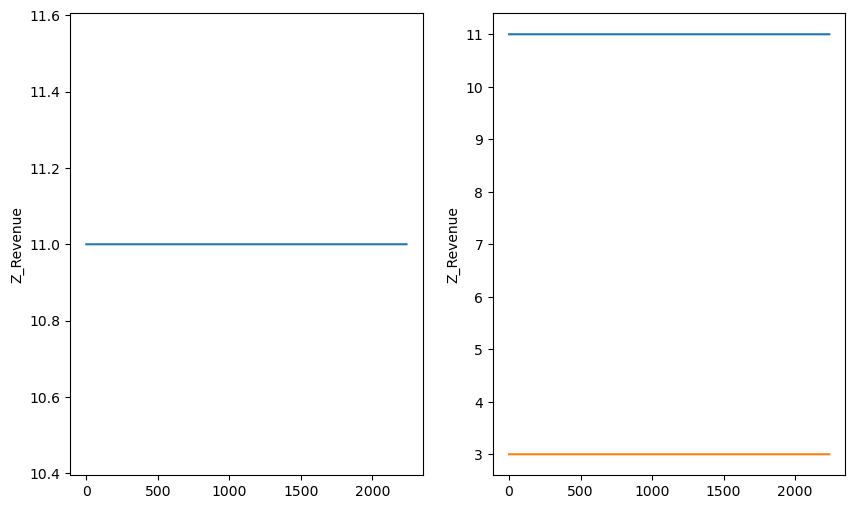

In [18]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.lineplot(data = df.Z_Revenue)
plt.subplot(1,2,2)
sns.lineplot(data = df.Z_Revenue)
sns.lineplot(data = df.Z_CostContact)



**As we can see**
- The column ```Z_CostContact```, ```Z_Revenue``` does have constant values. As this columns does not have any varience, we can drop this column

In [19]:
df = df.drop(columns = ['Z_CostContact','Z_Revenue'])
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

In [20]:
df.columns.value_counts().sum()

np.int64(27)

### Categorical Features

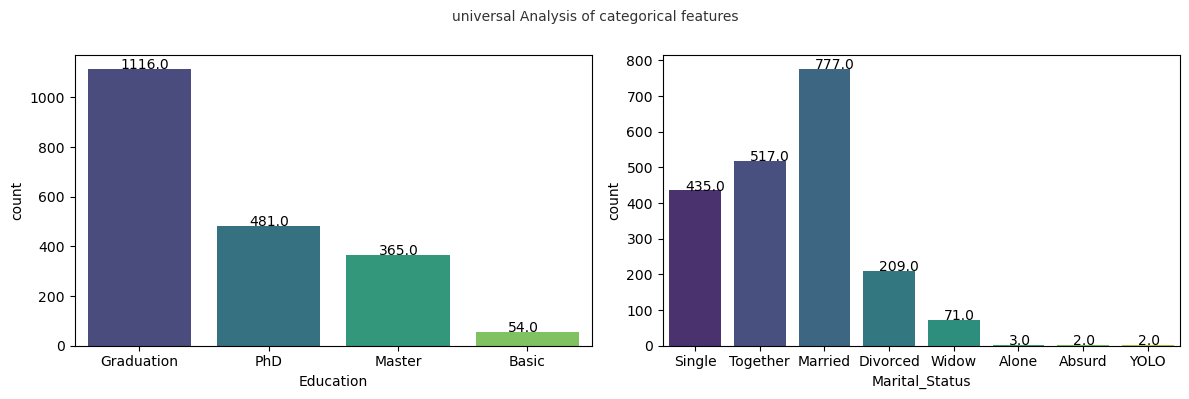

In [21]:
#categorical features

plt.figure(figsize = (12,7))
plt.suptitle('universal Analysis of categorical features', fontsize = 'medium',alpha = 0.8,y =1.)
for i in range (0,len(cat_features)):
    plt.subplot(2,2,i+1)
    ax = sns.countplot(x = cat_features[i], data = df, palette='viridis')
    if df[cat_features[i]].value_counts().count()<10:
        for p in ax.patches:
            ax.annotate('{:.1f}'.format(p.get_height()),(p.get_x()+0.25,p.get_height()+0.01))
    plt.xlabel(cat_features[i])
plt.tight_layout()
plt.show()

**Report**
- For column **``Education``**
    - Most of the Customers are falling into **Graduation** category.
    - Respectively, **PhD, Master Education, Basic and *2n Cycle** are also present.
    
    _2nCycle_ -  Multidisciplinary degree programmes are second cycle degree programmes in which the teaching system meets the requirements of two different classes
    
- For column **```Maritial_Status```**
    - For about **777** customers are married. 
    - **Together, single, divorced, widow** are noticeable where **Alone, Absurd and YOLO** categories are very less.

In [22]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
139,1461,1965,PhD,Divorced,36921,1,1,2013-07-28,74,17,1,12,3,1,4,2,2,0,3,7,0,0,0,0,0,0,0.0
911,4654,1992,Graduation,Together,75114,0,0,2013-11-07,40,571,12,523,63,60,24,1,3,10,5,2,0,0,0,0,0,0,0.0
853,7186,1966,PhD,Together,30843,1,1,2014-05-26,43,24,0,2,0,0,9,2,1,1,2,5,1,0,0,0,0,0,0.0
1140,849,1953,Master,Together,56129,0,1,2013-06-20,65,320,48,133,39,72,48,4,6,2,10,4,0,0,0,0,0,0,0.0
675,6961,1974,Graduation,Married,26751,2,0,2014-05-22,26,1,1,5,0,3,1,1,1,0,2,8,0,0,0,0,0,0,0.0


In [23]:
df = df[df.Dt_Customer.dt.year != 1970]

<Axes: xlabel='YEAR', ylabel='CUSTOMER_JOINED'>

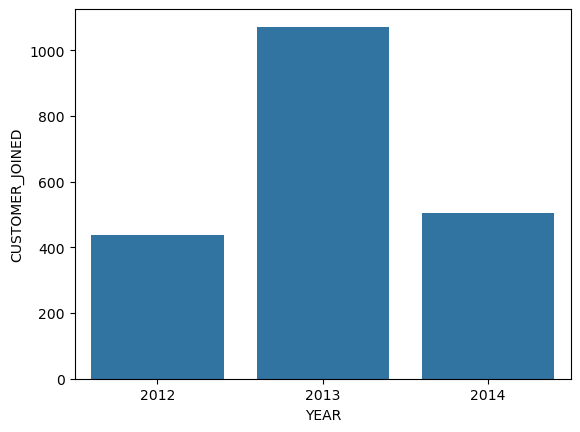

In [24]:
df1 = df.copy()
df1["YEAR"] = df.Dt_Customer.dt.year
customer_joined_per_year = df1.groupby(by = "YEAR",axis = 0)[['ID']].count()
customer_joined_per_year = customer_joined_per_year.reset_index()
customer_joined_per_year.columns = ['YEAR','CUSTOMER_JOINED']
sns.barplot(data =customer_joined_per_year, x = customer_joined_per_year['YEAR'],y = customer_joined_per_year['CUSTOMER_JOINED'])

**Report**
- By this report, we can say that, most number of customers have joined in the year **2013**
- The number of customers got increased in year 2013 but in the year 2014, the number of customers got decreased.

### Multivariate Analysis

* Multivariate analysis is the analysis of more than one variable.

### Check Multicollinearity in Numerical features

In [25]:
corr = df.select_dtypes(include='number')

In [26]:
corr = corr.drop(columns="ID")

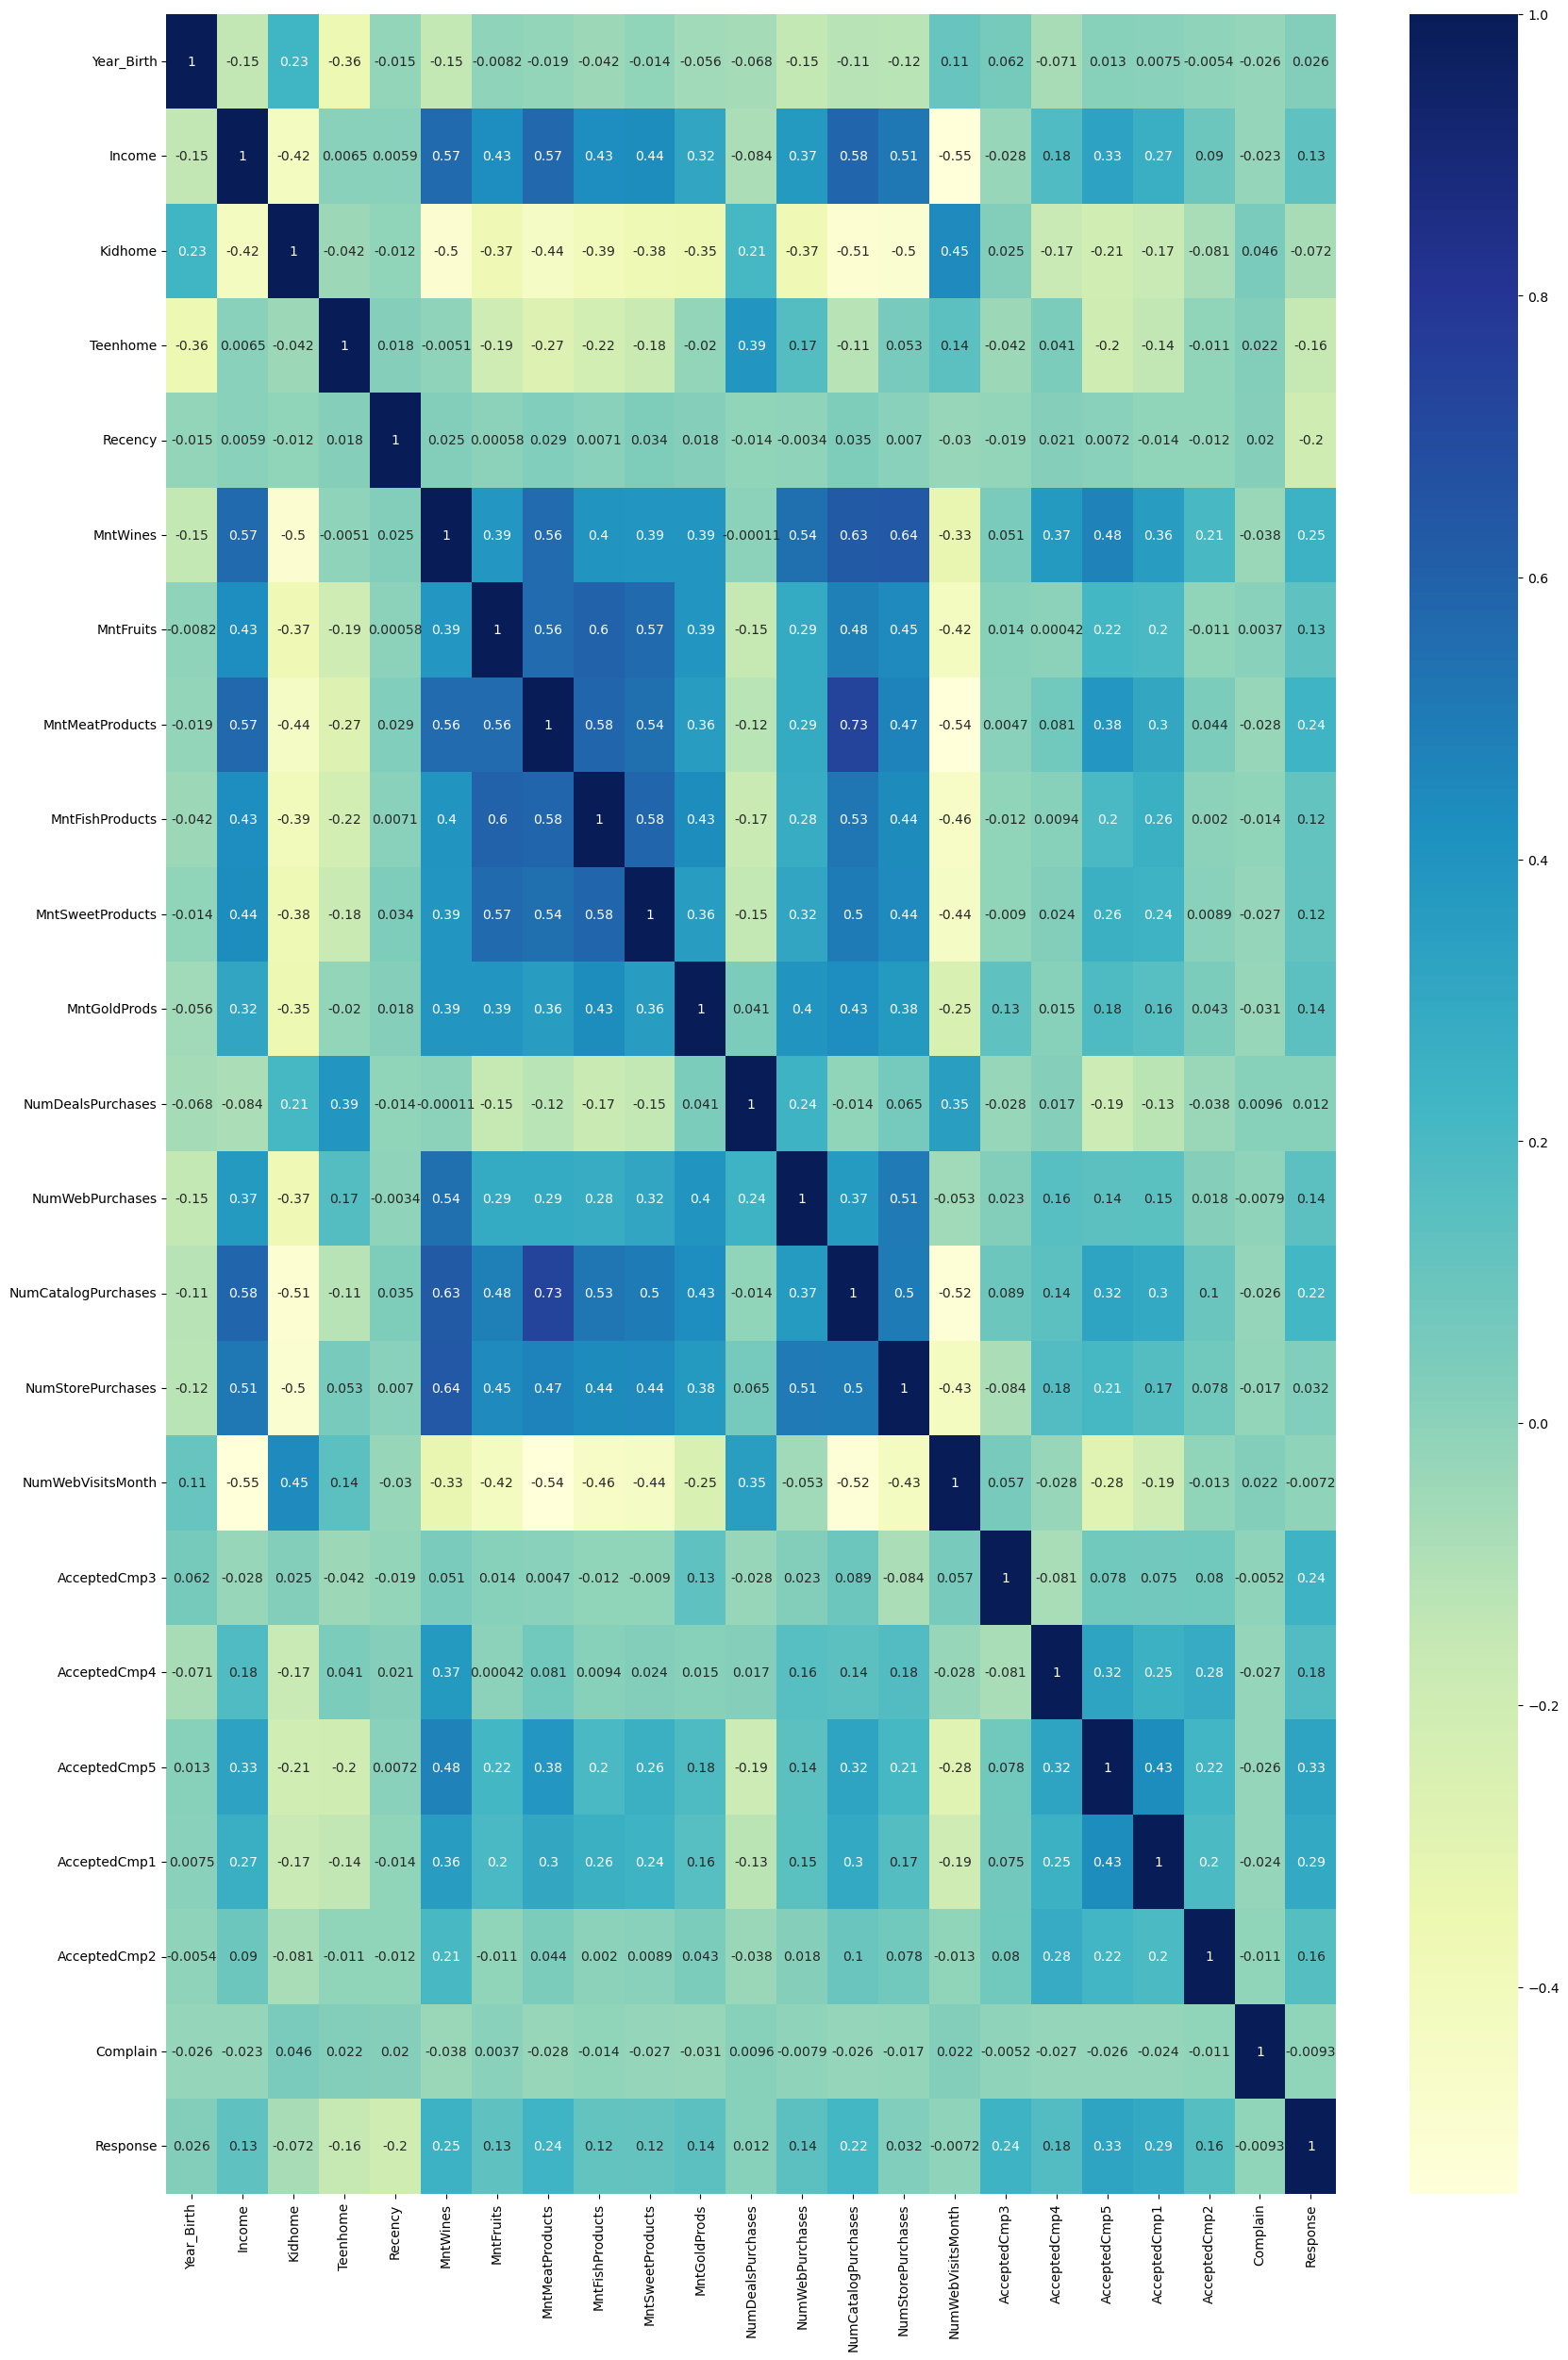

In [27]:
plt.figure(figsize=(20,30))
sns.heatmap(corr.corr(), annot= True,cmap = "YlGnBu")
plt.show()

**let's check the correlation in vif now**

**We can see that income does has some null values. Let's first input those values**

In [28]:
#let's fill the income column with median income
df1.Income.fillna(df1.Income.median(), inplace=True)

## Feature Extraction


#### The following code creates features that would be helpful to describe the profile of the customer 

In [29]:
df1 = df1.drop(columns="ID", axis =1)
from datetime import datetime
#Creating new field to store the age of customer
df1["AGE"] =pd.Timestamp.now().year - df1['Year_Birth']
# recoding the customers education level to numeric form (0: Basic, 1: Graduation, 2: Master, 3: PHD)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df1["Education"] = encoder.fit_transform(df1["Education"])
print("Education Encoding")
for index, class_name in enumerate(encoder.classes_):
    print(F"{index}:{class_name}")
# recoding the customers marital status to numeric form (0:Absurd 1:Alone, 2:Divorced ,3:Married ,4:Single ,5:Together ,6:Widow ,7:YOLO)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df1["Marital_Status"] = encoder.fit_transform(df1["Marital_Status"])
print("-------------")
print("Marital_Status Encoding")
for index, class_name in enumerate(encoder.classes_):
    print(F"{index}:{class_name}")
# creating a new field to store the number of children in the household
df1["Children"] = df1["Kidhome"]+df1["Teenhome"]
df1.drop(columns=["Kidhome","Teenhome"], inplace= True)
# creating Family_Size
df1["Family_size"] = df1["Children"] + df1["Marital_Status"]+1
#  creating a new field to store the total spending of the customer
df1['Total_Spending'] = df1.iloc[:,[6,7,8,9,10,11]].sum(axis = 1)
#  creating a new field how many promo done for customer
promo_col = ['AcceptedCmp3','AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2']
df1.columns.get_indexer(promo_col)
df1['Total_Promo'] = df1.iloc[:,[17,18,19,20,21]].sum(axis = 1)
# The following code works out how long customer has been with the company 

df1["Days_as_Customer"] = (pd.Timestamp.now() - df1["Dt_Customer"]).dt.days
# Total number of promotions customer responced to 
df1['Offers_Responded_To'] = df1.iloc[:,[17,18,19,20,21,23]].sum(axis = 1)
# parental status of a customer
df1['parental_status'] = np.where(df1['Children']>0,1,0)
# dropping columns which are already used to create new features
columns_to_drop = ['Year_Birth']
df1.drop(columns = columns_to_drop, axis = 1, inplace=True)
df1.rename(columns={"Marital_Status": "Marital Status","MntWines": "Wines","MntFruits":"Fruits",
                   "MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets",
                   "MntGoldProds":"Gold","NumWebPurchases": "Web","NumCatalogPurchases":"Catalog",
                   "NumStorePurchases":"Store","NumDealsPurchases":"Discount Purchases"},
          inplace = True)

df1 = df1[["AGE","Education","Marital Status","parental_status","Children","Income","Total_Spending","Days_as_Customer","Recency","Wines","Fruits","Meat","Fish","Sweets","Gold","Web","Catalog","Store","Discount Purchases","Total_Promo","NumWebVisitsMonth"]]



Education Encoding
0:Basic
1:Graduation
2:Master
3:PhD
-------------
Marital_Status Encoding
0:Absurd
1:Alone
2:Divorced
3:Married
4:Single
5:Together
6:Widow
7:YOLO


In [30]:
numeric_features = df1.select_dtypes(include = ['number','bool']).columns.tolist()
categorical_features = df1.select_dtypes(include=['object', 'category']).columns.tolist()
continuous_features = [i for i in numeric_features if len(df1[i].unique())>=10]
print('Names of continues features :',continuous_features)


Names of continues features : ['AGE', 'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store', 'Discount Purchases', 'NumWebVisitsMonth']


In [31]:
continuous_features

['AGE',
 'Income',
 'Total_Spending',
 'Days_as_Customer',
 'Recency',
 'Wines',
 'Fruits',
 'Meat',
 'Fish',
 'Sweets',
 'Gold',
 'Web',
 'Catalog',
 'Store',
 'Discount Purchases',
 'NumWebVisitsMonth']

In [32]:
numeric_features

['AGE',
 'Education',
 'Marital Status',
 'parental_status',
 'Children',
 'Income',
 'Total_Spending',
 'Days_as_Customer',
 'Recency',
 'Wines',
 'Fruits',
 'Meat',
 'Fish',
 'Sweets',
 'Gold',
 'Web',
 'Catalog',
 'Store',
 'Discount Purchases',
 'Total_Promo',
 'NumWebVisitsMonth']

### Multicollinearity Check
#### Variance Inflation Factor (VIF)
* Multicollinearity occurs when there are two or more independent variables in a multiple regression model, which have a high correlation among themselves. When some features are highly correlated.
* Multicollinearity can be detected using various techniques, one such technique being the Variance Inflation Factor(VIF).

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [34]:
def compute_vif(considered_features,df1):
    X = df1[considered_features].copy()
    # to calculate VIF requires a constant
    X["intercept"] = 1
    #create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Features"] = X .columns
    vif["vif"]  = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
    vif = vif[vif['Features']!='intercept']
    return vif

# we will remove the datetime column which is not required for vif checking
count_features = continuous_features.copy()
# we will not chech vif for total spending, as it is the summation of Wines,Fruits,Meat,Fish,Sweets,Gold.
count_features.remove('Total_Spending')
compute_vif(count_features,df1)


,Features,vif
0,AGE,1.075629
1,Income,2.064233
2,Days_as_Customer,1.278384
3,Recency,1.004817
4,Wines,2.644922
5,Fruits,1.951294
6,Meat,2.891395
7,Fish,2.093074
8,Sweets,1.896580
9,Gold,1.471969


#### Most research papers consider a VIF (Variance Inflation Factor) > 10 as an indicator of multicollinearity, but some choose a more conservative threshold of 5.
**As we can see the Vif for the columns are less than 5, we can safely assume that the data has not such correlations**.

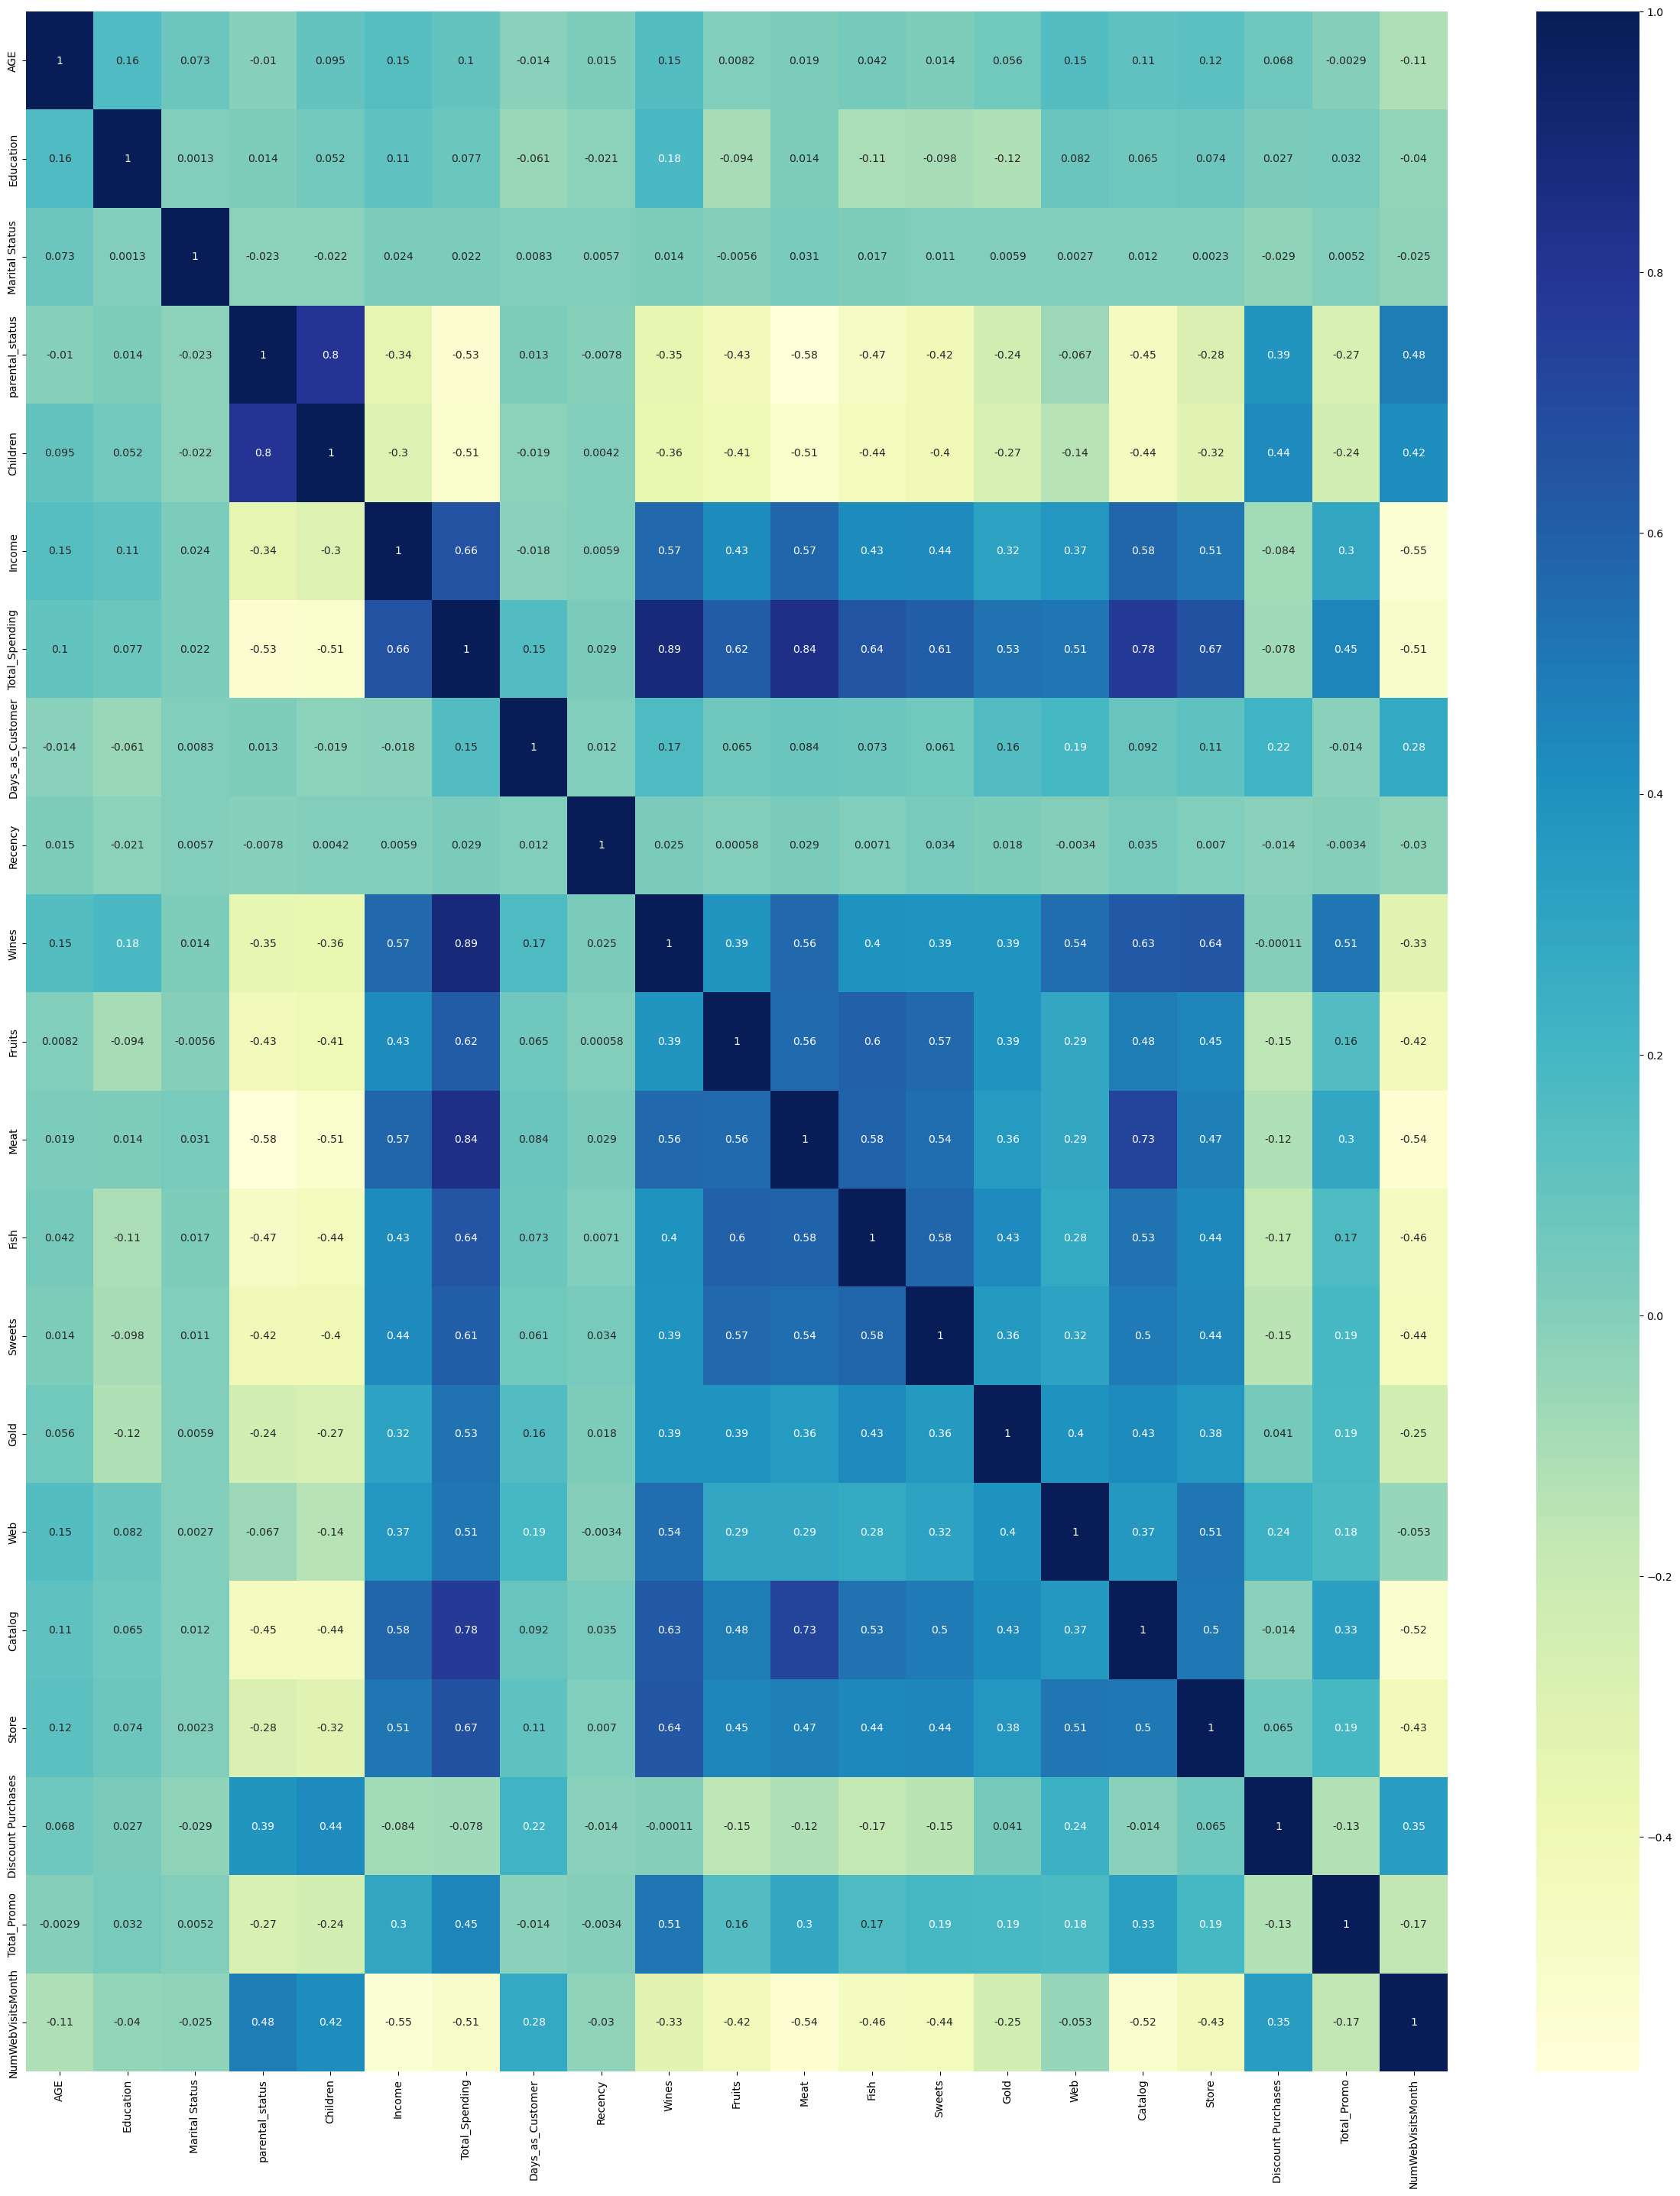

In [35]:
plt.figure(figsize = (30,35))
num_features = numeric_features.copy()

sns.heatmap(df1[num_features].corr(), annot=True, cmap="YlGnBu")
plt.show()

### Checking Null Values

In [36]:
df1.isnull().sum()

AGE                   0
Education             0
Marital Status        0
parental_status       0
Children              0
Income                0
Total_Spending        0
Days_as_Customer      0
Recency               0
Wines                 0
Fruits                0
Meat                  0
Fish                  0
Sweets                0
Gold                  0
Web                   0
Catalog               0
Store                 0
Discount Purchases    0
Total_Promo           0
NumWebVisitsMonth     0
dtype: int64

**We can see there is null values in Income column, We can impute the null values in feature engineering steps.**

## Initial Analysis Report


* **There are missing values in the Income column.**
* **The ID column can be deleted because each row has unique values.**
* **There is no such target feature, so we can do clustering.**

## 4. Visualization

### 4.1 Purchease trend by Relationship Status

In [37]:
raw_df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Unnamed: 29
0,5524,1957,Graduation,Single,58138,0,0,2012-09-04 00:00:00,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1.0,NaN
1,2174,1954,Graduation,Single,46344,1,1,2014-03-08 00:00:00,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0.0,NaN
2,4141,1965,Graduation,Together,71613,0,0,2013-08-21 00:00:00,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0.0,NaN
3,6182,1984,Graduation,Together,26646,1,0,2014-02-10 00:00:00,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0.0,NaN
4,5324,1981,PhD,Married,58293,1,0,2014-01-19 00:00:00,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223,0,1,2013-06-13 00:00:00,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0.0,NaN
2236,4001,1946,PhD,Together,64014,2,1,2014-06-10 00:00:00,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0.0,NaN
2237,7270,1981,Graduation,Divorced,56981,0,0,2014-01-25 00:00:00,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0.0,NaN
2238,8235,1956,Master,Together,69245,0,1,2014-01-24 00:00:00,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0.0,NaN


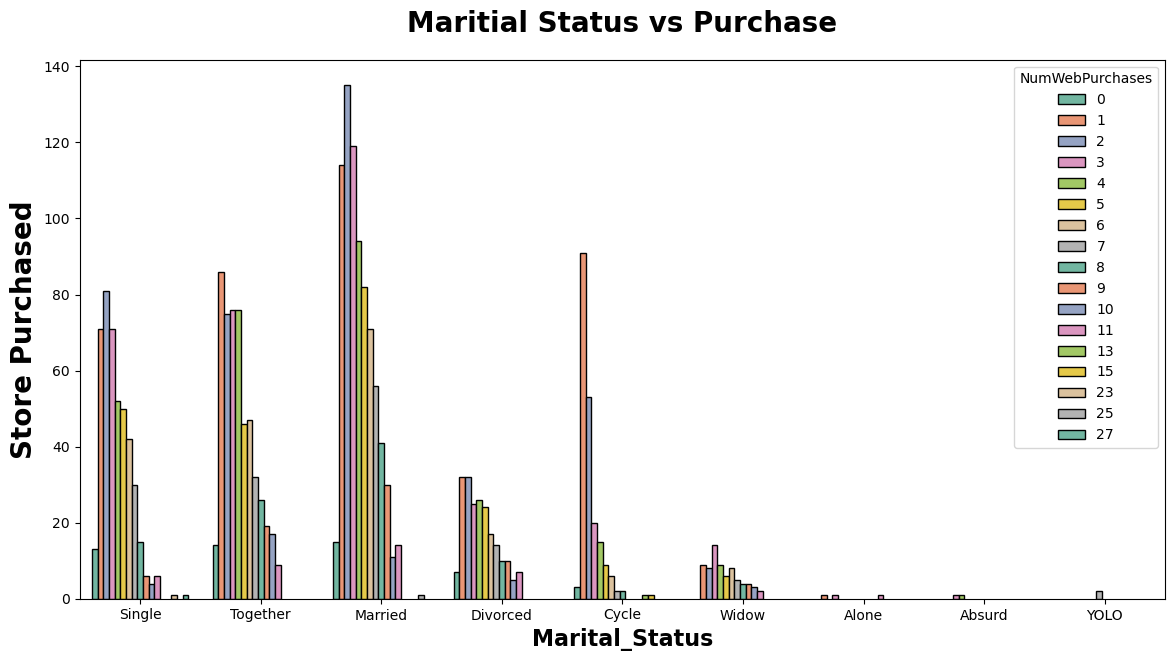

In [38]:
plt.subplots(figsize =[14,7])
sns.countplot(x = 'Marital_Status', data= raw_df, hue = 'NumWebPurchases', ec = 'black', palette='Set2')
plt.title('Maritial Status vs Purchase', weight = 'bold', fontsize = 20, pad = 20)
plt.ylabel('Store Purchased', weight = 'bold', fontsize = 20)
plt.xlabel('Marital_Status', weight = 'bold', fontsize = 16)
plt.show()

**Report:**
* As per the Chart, **Married** Customers bought more store products.
* **Divorces, Widow, Alone, Absurd and YOLO** category people baught very less.

**Report:**
* As per the Chart Male and Female customers who are Married has Purchased more than Divorced and Single and UnMarried.
* 33.18% of Single Customers, 24% of UnMarried Customers
* Followed by approx 13% of Divorced and Married Customers

In [39]:
raw_df["Dt_Customer"] = pd.to_datetime(raw_df["Dt_Customer"])

In [40]:
dates = []
for i in raw_df["Dt_Customer"]:
    i = i.date()
    dates.append(i)

print(f"Newest Customer Enrolement date is {max(dates)}")
print(f"Oldest customer's enrolement date is {min(dates)}")

Newest Customer Enrolement date is 2014-06-29
Oldest customer's enrolement date is 1970-01-01


In [41]:
raw_df.shape

(2240, 30)

In [42]:
dates = []
raw_df["Dt_Customer"] = pd.to_datetime(raw_df["Dt_Customer"])
for i in raw_df["Dt_Customer"]:
    i = i.date()
    dates.append(i)  

print(f"Newest customer's enrolment date is {max(dates)}")
print(f"Oldest customer's enrolment date is {min(dates)}")

Newest customer's enrolment date is 2014-06-29
Oldest customer's enrolment date is 1970-01-01


**Report**
*The dataset contains customer data from `2012-07-30` to `2014-06-29`*

48


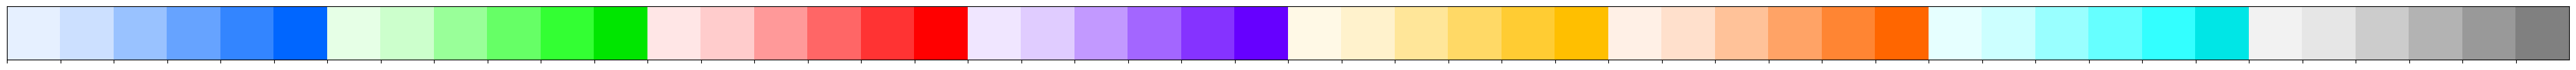

In [43]:
all_colors = [
    # Blues
    "#e6f0ff", "#cce0ff", "#99c2ff", "#66a3ff", "#3385ff", "#0066ff",
    # Greens
    "#e6ffe6", "#ccffcc", "#99ff99", "#66ff66", "#33ff33", "#00e600",
    # Reds/Pinks
    "#ffe6e6", "#ffcccc", "#ff9999", "#ff6666", "#ff3333", "#ff0000",
    # Purples
    "#f0e6ff", "#e0ccff", "#c299ff", "#a366ff", "#8533ff", "#6600ff",
    # Yellows
    "#fff9e6", "#fff2cc", "#ffe699", "#ffd966", "#ffcc33", "#ffbf00",
    # Oranges
    "#fff0e6", "#ffe0cc", "#ffc299", "#ffa366", "#ff8533", "#ff6600",
    # Teals/Cyans
    "#e6ffff", "#ccffff", "#99ffff", "#66ffff", "#33ffff", "#00e6e6",
    # Greys
    "#f2f2f2", "#e6e6e6", "#cccccc", "#b3b3b3", "#999999", "#808080",
]

print(len(all_colors))  # 48 colors total

sns.palplot(all_colors)

In [44]:
# setting plotting options

sns.set_style("white")
sns.set(rc = {"axes.facecolor":"#cce0ff","figure.facecolor":"#cce0ff"})
sns.set_context("poster",font_scale = .7)

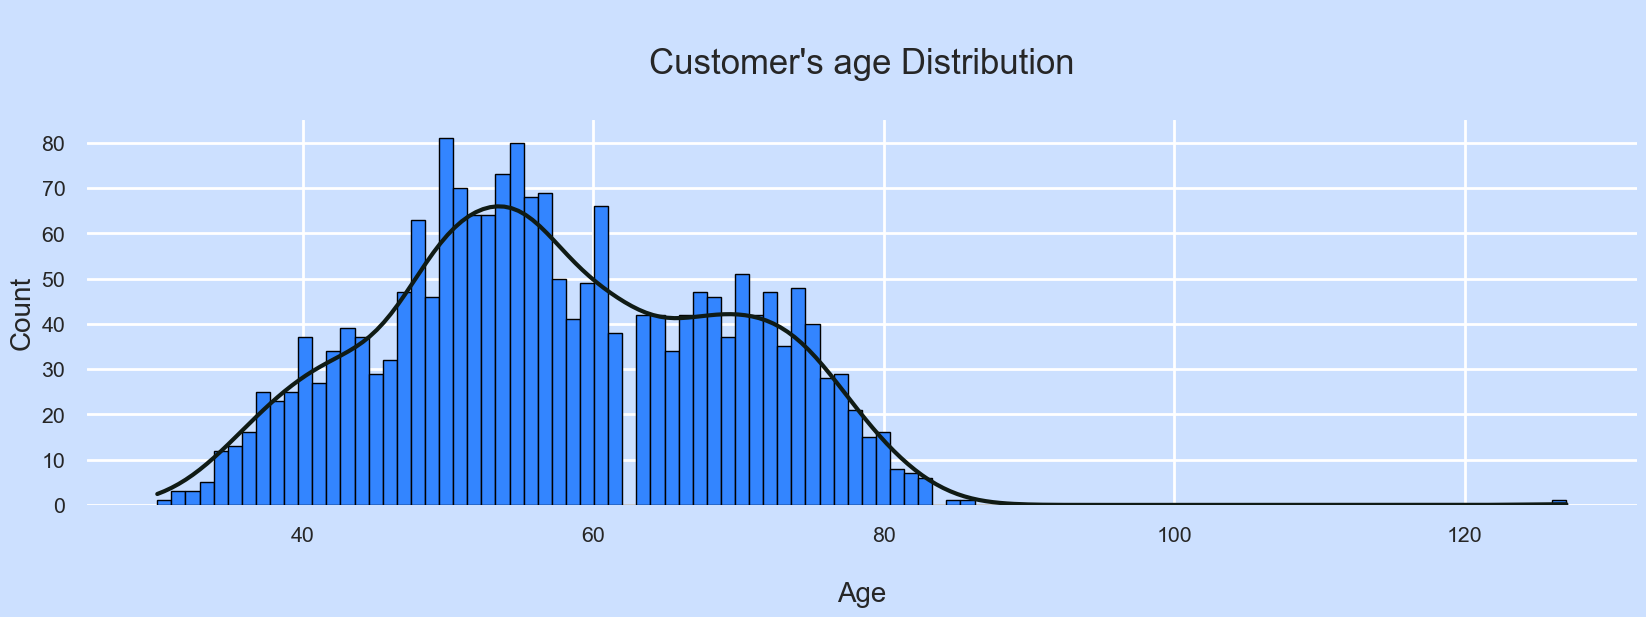

In [45]:
plt.subplots(figsize = [20,5])
plt.title("Let's have a look on the distribution of customer's age :",weight = 'bold', fontsize = 20,pad = 20)
p = sns.histplot(df1["AGE"],color='#3385ff',kde = True, bins=100,alpha = 1, fill = True, edgecolor = "black")
p.axes.lines[0].set_color("#101B15")
p.axes.set_title("\nCustomer's age Distribution\n", fontsize = 25)
plt.ylabel("Count",fontsize = 20)
plt.xlabel("\nAge",fontsize=20)
sns.despine(left=True, bottom=True)
plt.show()


**reports:**

* We can see it's a normal distribution of customer's age.
* We can see there's some outliers in the distribution. So we can remove the outliers from the Age column.

**As we can see most of the customers' age is 80 or less. So we can filter the data by age <90**

#### Customer's Age Distribution After filter application(less than 90 yrs)

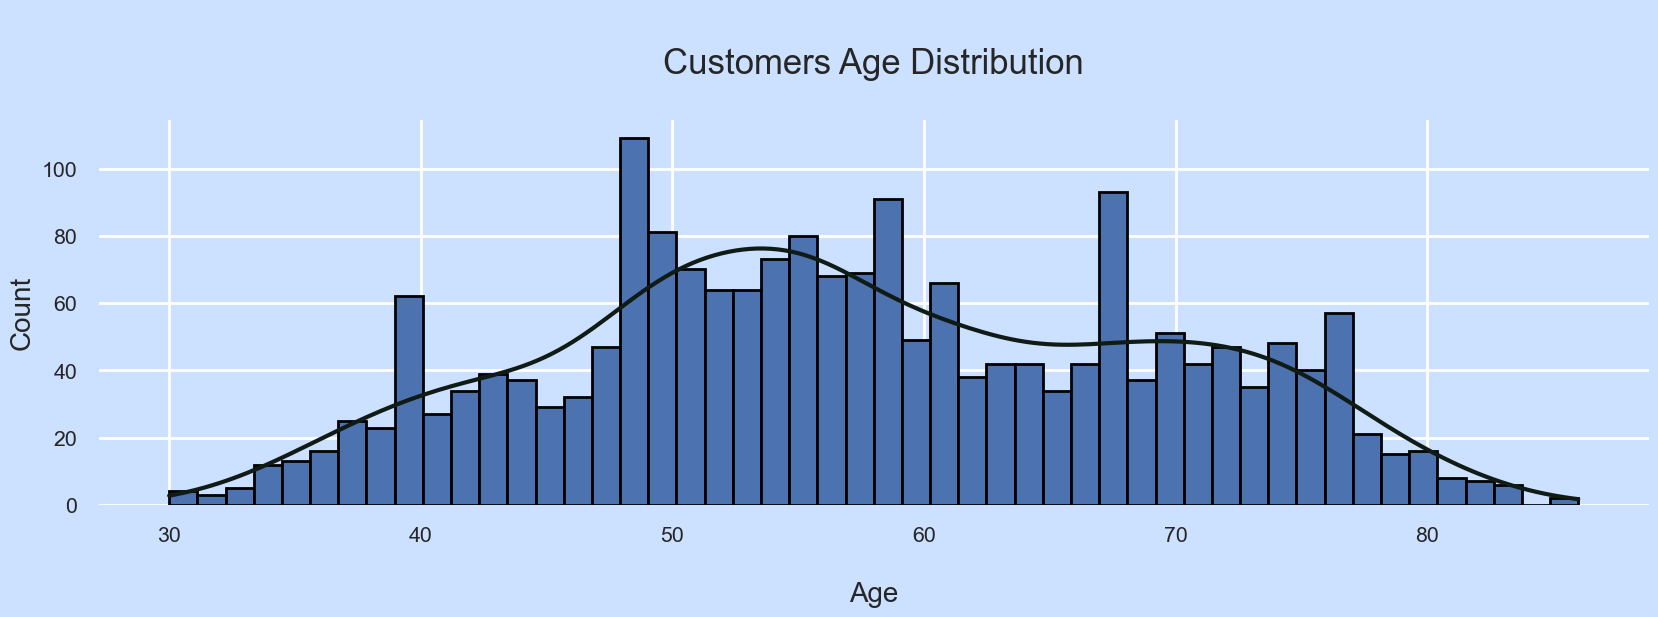

In [46]:
df1 = df1[df1["AGE"]<90]
plt.subplots(figsize = (20,5))
plt.title("Let's have a look again on the distribution of customer's age :", fontsize = 20, pad = 20,weight = "bold")
p = sns.histplot(x = "AGE",data = df1, kde = True, bins = 50, alpha = 1, fill = True,edgecolor = "black")
p.axes.lines[0].set_color("#101B15")
p.axes.set_title("\nCustomers Age Distribution\n", fontsize = 25)
plt.ylabel("Count",fontsize = 20)
plt.xlabel("\nAge",fontsize=20)
sns.despine(left=True, bottom=True)
plt.show()

**report**
* We can see it's a normal distribution of customer's age.
* Most of the customers are from 43 to 57.

## Customers income Spending Distribution

In [47]:
df1

,AGE,Education,Marital Status,parental_status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total_Promo,NumWebVisitsMonth
0,69,1,4,0,0,58138,1617,5080,58,635,88,546,172,88,88,8,10,4,3,0,7
1,72,1,4,1,2,46344,27,4530,38,11,1,6,2,1,6,1,1,2,2,0,5
2,61,1,5,0,0,71613,776,4729,26,426,49,127,111,21,42,8,2,10,1,0,4
3,42,1,5,1,1,26646,53,4556,26,11,4,20,10,3,5,2,0,4,2,0,6
4,45,3,3,1,1,58293,422,4578,94,173,43,118,46,27,15,5,3,6,5,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,59,1,3,1,1,61223,1341,4798,46,709,43,182,42,118,247,9,3,4,2,0,5
2236,80,3,5,1,3,64014,444,4436,56,406,0,30,0,0,8,8,2,5,7,1,7
2237,45,1,2,0,0,56981,1241,4572,91,908,48,217,32,12,24,2,3,13,1,1,6
2238,70,2,5,1,1,69245,843,4573,8,428,30,214,80,30,61,6,5,10,2,0,3


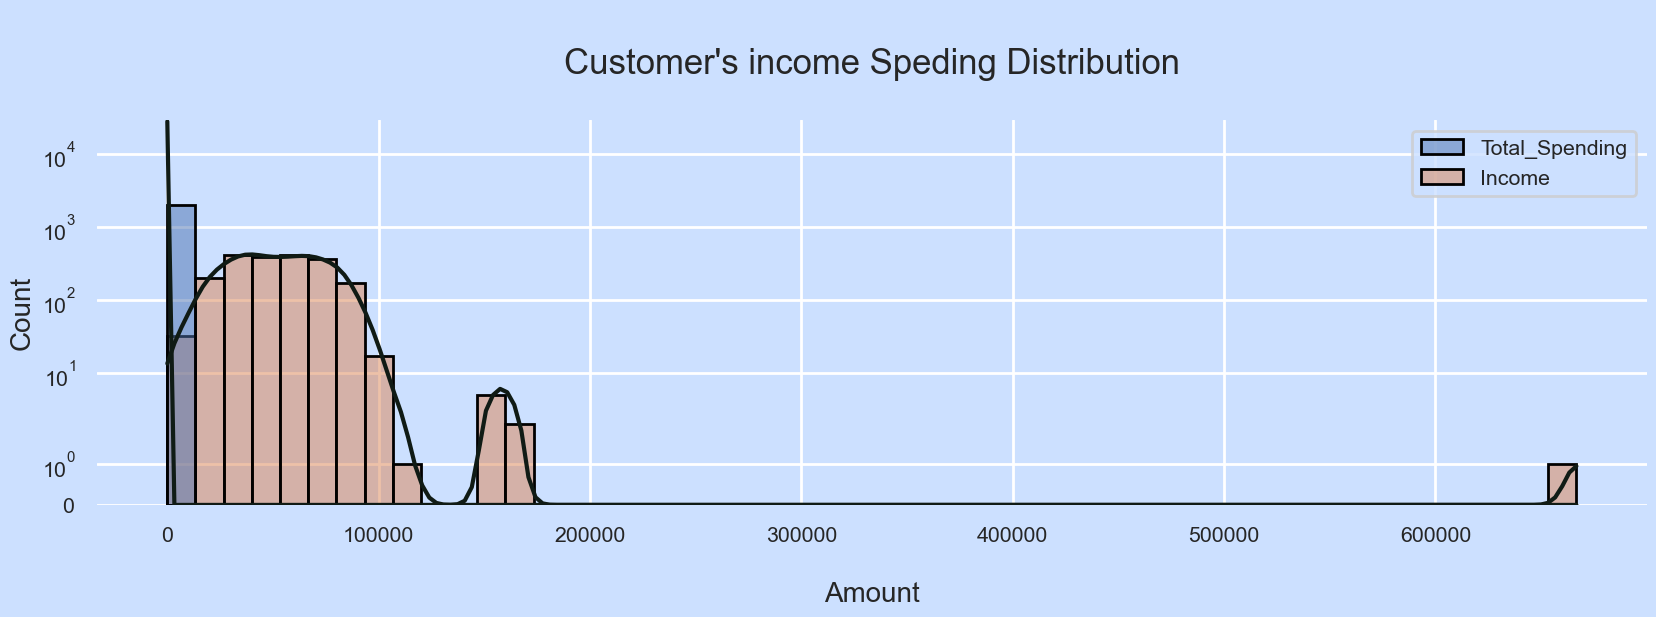

In [48]:
plt.subplots(figsize = [20,5])
p = sns.histplot(df1[["Total_Spending","Income"]],bins = 50, kde = True, fill = True, edgecolor = "black")
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's income Speding Distribution\n", fontsize = 25)
plt.ylabel("Count", fontsize = 20)
plt.xlabel("\nAmount", fontsize = 20)
sns.despine(left = True, bottom = True)
plt.show()

- **reports**

    - Income Column Does have some outliers which are seen after 60,00,00, so we can filter them out

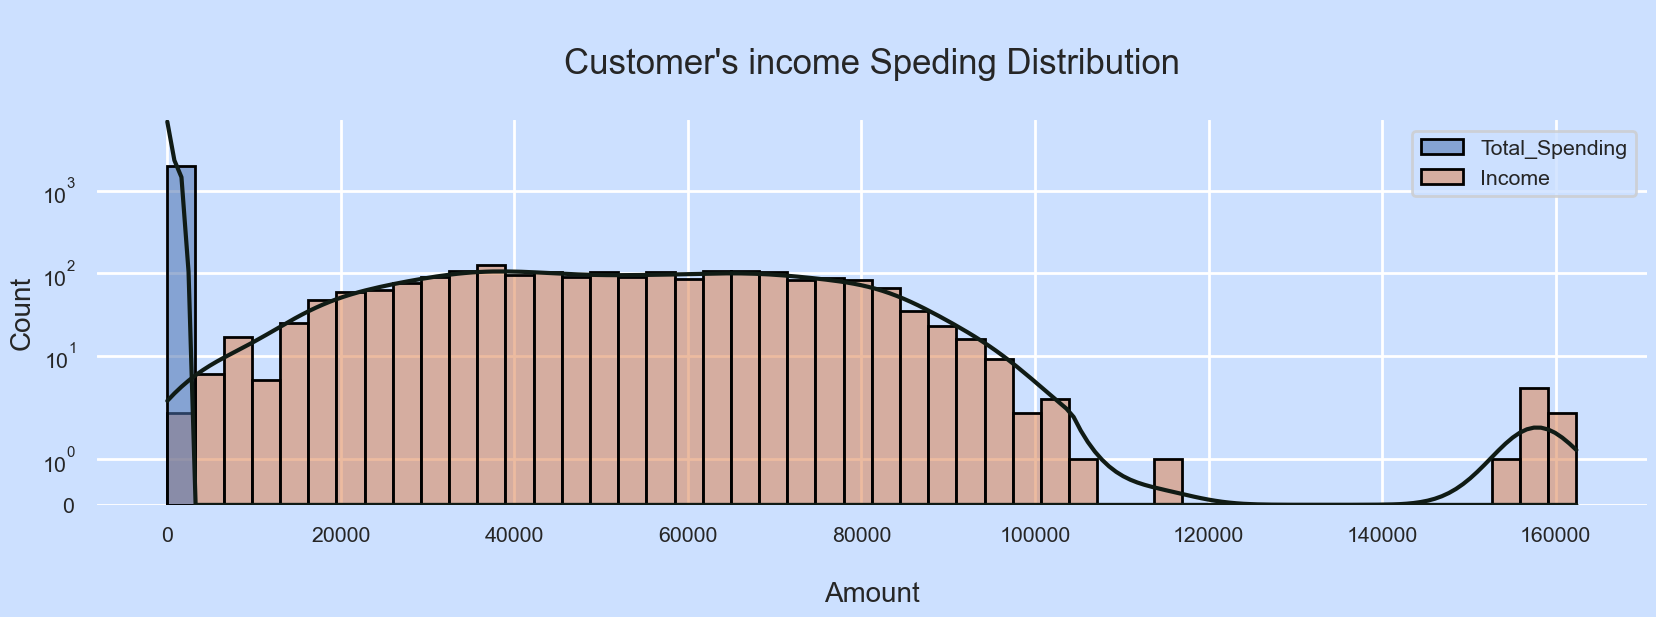

In [49]:
df1 = df1[df1["Income"]<600000]
plt.subplots(figsize = [20,5])
p = sns.histplot(df1[["Total_Spending","Income"]],bins = 50, kde = True, fill = True, alpha = 0.55,edgecolor = "black")
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's income Speding Distribution\n", fontsize = 25)
plt.ylabel("Count", fontsize = 20)
plt.xlabel("\nAmount", fontsize = 20)
sns.despine(left = True, bottom = True)
plt.show()

**Insights:**

- Most of the customers income range is in between 20000 to 80000
- Bust almost all customers spend very few portion of their income.

#### Customer Education Level report

In [50]:
counts = df["Education"].value_counts()
labels = counts.index.tolist()
values = counts.values.tolist()


In [51]:
values

[1116, 481, 365, 54]

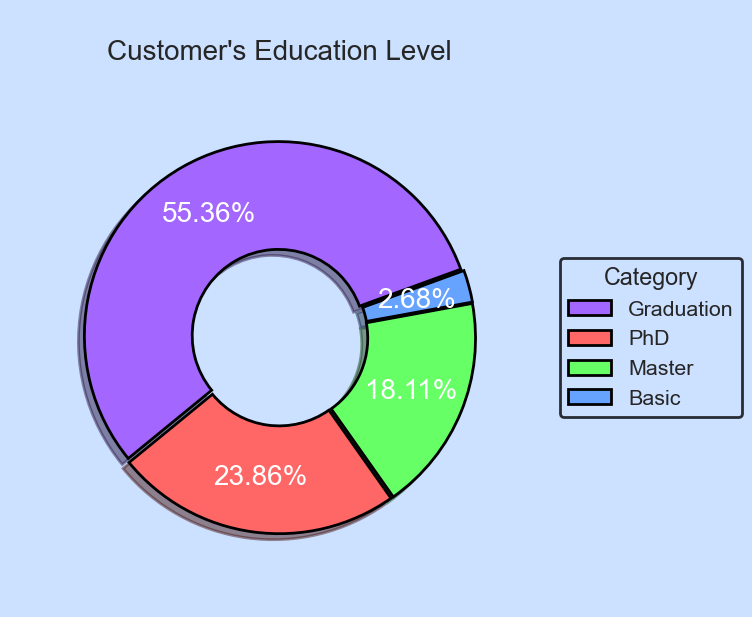

In [52]:
plt.subplots(figsize = (7,7))
wedges, texts, autotexts = plt.pie([df["Education"].value_counts()[0],
                                    df["Education"].value_counts()[1],
                                    df["Education"].value_counts()[2],
                                    df["Education"].value_counts()[3]],
                                    explode = (0.01,0.01,0.01,0.01),
                                    textprops = dict(size = 20,color = "white"),
                                    autopct = "%.2f%%",
                                    pctdistance = 0.72,
                                    radius = 0.9,
                                    colors = ["#a366ff","#ff6666","#66ff66","#66a3ff"],
                                    shadow = True,
                                    wedgeprops =  dict(width = 0.5, edgecolor = "black",
                                    linewidth = 2),
                                    startangle = 20)
plt.legend(wedges,labels,title = "Category", loc = "center left", bbox_to_anchor= (1,0,0.5,1), edgecolor = "black")
plt.title("\nCustomer's Education Level",fontsize=20)
plt.show()

**Insights:**

- Customers have 4 education levels : Basic, Graduation, Master, PhD
- 55.36% have completed graduation, 23.86% are doing masters, 18.11% are persuing PhD,  2.68% have done basic education 

#### Education level wise spending distribution

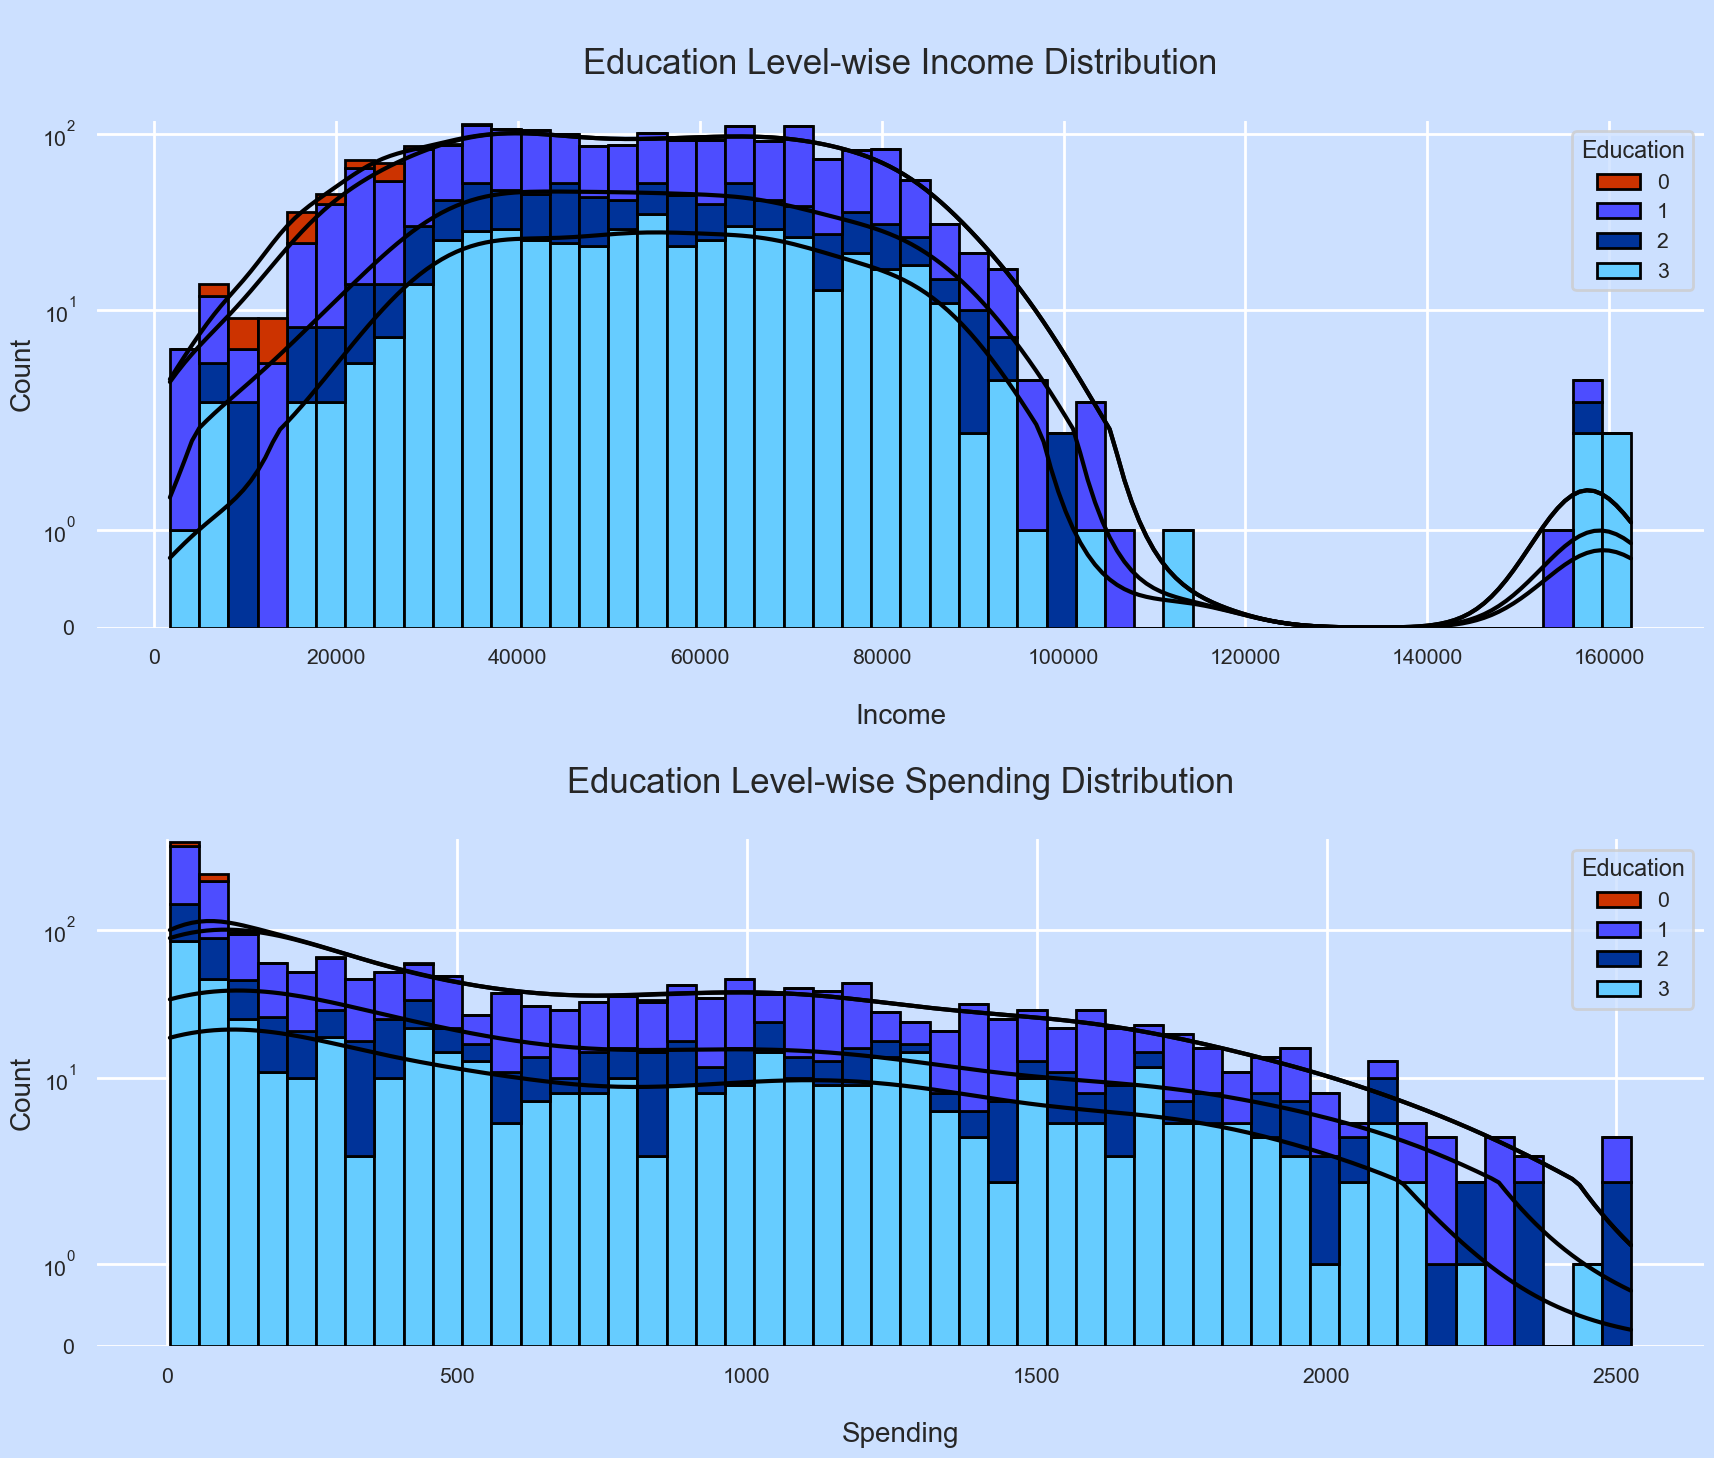

In [53]:
fig , axes = plt.subplots(2,1,figsize = (20,16),sharex = False)
plt.tight_layout(pad = 7.0)

colors = ["#cc2900","#0000ff","#66ffff", "#009999","#99ff66"]
colors2 = ["#cc3300","#4d4dff","#003399","#66ccff","#009999"]
sns.histplot(data = df1, x = "Income", hue = "Education", multiple = "stack", palette=colors2, ax = axes[0], kde = True, bins = 50, alpha = 1, fill = True, edgecolor = "black")
axes[0].lines[0].set_color("#000000")
axes[0].lines[1].set_color("#000000")
axes[0].lines[2].set_color("#000000")
axes[0].lines[3].set_color("#000000")

axes[0].set_yscale("symlog")
axes[0].set_title("\nEducation Level-wise Income Distribution\n",fontsize=25)
axes[0].set_ylabel("Count",fontsize=20)
axes[0].set_xlabel("\nIncome",fontsize=20)

sns.histplot(data = df1, x = "Total_Spending", hue = "Education", multiple= "stack",palette=colors2, ax = axes[1], kde = True,bins = 50, alpha = 1, fill = True, edgecolor = "black")
axes[1].lines[0].set_color("#000000")
axes[1].lines[1].set_color("#000000")
axes[1].lines[2].set_color("#000000")
axes[1].lines[3].set_color("#000000")
axes[1].set_yscale("symlog")
axes[1].set_title("\nEducation Level-wise Spending Distribution\n",fontsize=25)
axes[1].set_ylabel("Count",fontsize=20)
axes[1].set_xlabel("\nSpending",fontsize=20)
sns.despine(left=True, bottom=True)
plt.show()

0:Basic
1:Graduation
2:Master
3:PhD

**Insights:**

- Most of the undergraduate level customer's income range is in between 10000 to 40000 and spending in between 0 to 1400.
- Most of the graduate level customer's income range is in between 20000 to 85000 and spending in between 0 to 2000.
- Most of the postgraduate level customer's income range is in between 30000 to 80000 and spending in between 0 to 2000.

#### Customer Children Count

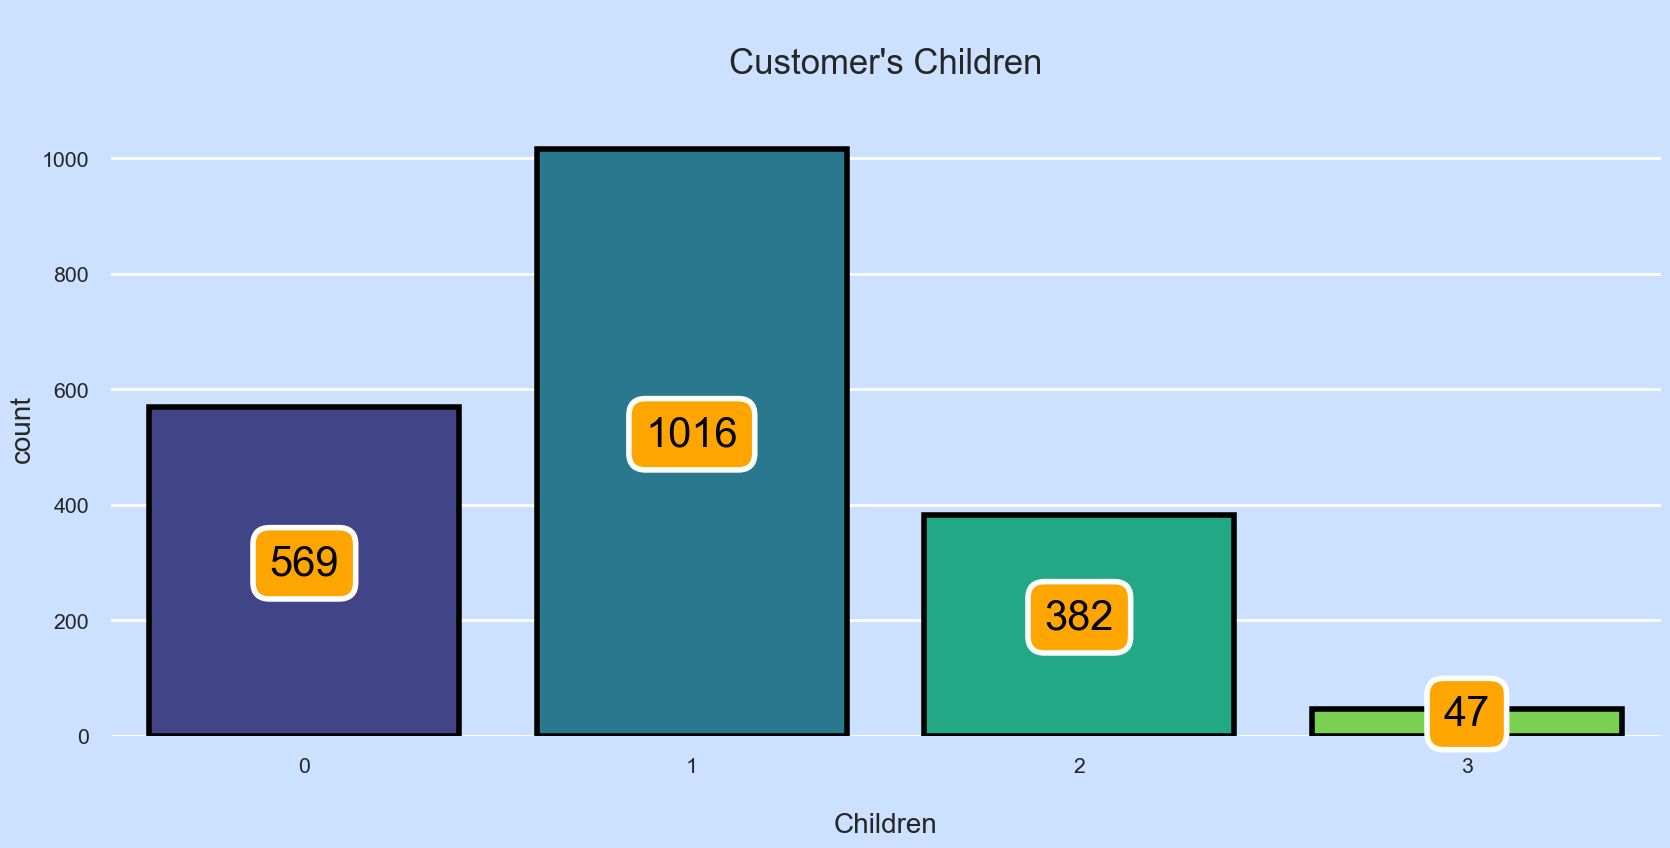

In [54]:
plt.subplots(figsize = (20,8))
p = sns.countplot(x = df1["Children"],palette = "viridis", saturation=1,edgecolor = "black",linewidth = 4)
p.axes.set_yscale("linear")
p.axes.set_title("\nCustomer's Children\n", fontsize  =25)
p.axes.set_ylabel("count",fontsize = 20)
p.axes.set_xlabel("\nChildren",fontsize = 20)
p.axes.set_xticklabels(p.get_xticklabels(),rotation = 0)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "orange", "edgecolor": "white", "linewidth" : 4, "alpha": 1})
    sns.despine(left=True, bottom=True)
plt.show()

**Report:**

- 569 customers have no child.
- Most of the customers have one child.
- 382 customers have two child.
- 47 customers have three child.

## Final report
- We have seen that this dataset has outliers in Wines, Fruits, Meat, Fish, Sweets, Gold, Age, Total_Spending columns
and multicollinearity in Total_Spending,Wines,Fruits,Meat,Fish,Sweets,Gold columns. So we have to handle those in feature engineering steps.

- We have dropped the ID column as it is not going to participate in any model building task
- The column Z_CostContact, Z_Revenue does have constant values. As this columns does not have any varience, we have dropped this column

- There are some columns which individually does not have such meaning, so in feature engineering we'll retrieve new columns. 